In [1]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 223.4 MB/s  0:00:020:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 293.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 395.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 300.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 411.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [tensorflow]4 [tensorflow]a]


In [2]:
!pip install tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 62.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.1/801.1 kB 122.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [tiktoken]


In [3]:
!pip install tqdm

In [4]:
!pip install torch

In [5]:
!pip install matplotlib

# Introduction

Let us build a Small Language Model (SLM) from scratch. We will try to keep the parameter size to 50-60 million.

Our goal is to generate creative and coherent text based on the input data.

## Step 1: Import the Dataset

TinyStories is a synthetic dataset of short stories that only contain words that a typical 3 to 4-year-olds usually understand, generated by GPT-3.5 and GPT-4. We can get it from HuggingFace.

In [15]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass
import numpy as np
import tiktoken
import os
import random
import json
from dataclasses import asdict
from contextlib import nullcontext
from tqdm.auto import tqdm

#!pip install -q -U datasets tiktoken optuna

enc = tiktoken.get_encoding("gpt2")


In [7]:
from datasets import load_dataset

ds = load_dataset("roneneldan/TinyStories")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

## Step 2: Tokenize the Dataset

In this step, we will do the following:

(1) Tokenize the dataset into tokenIDs.

(2) Create a file called "train.bin" and "validation.bin" where we will store the tokenIDs from the entire dataset.

(3) We make sure the tokenIDs are stored on a disk, rather than on the RAM for efficient computations.


In [8]:
!pip install tiktoken
import tiktoken
import os
import numpy as np
from tqdm.auto import tqdm

enc = tiktoken.get_encoding("gpt2")

# Some functions from https://github.com/karpathy/nanoGPT/blob/master/data/openwebtext/prepare.py

def process(example):
    ids = enc.encode_ordinary(example['text']) # encode_ordinary ignores any special tokens
    out = {'ids': ids, 'len': len(ids)}
    return out

if not os.path.exists("train.bin"):
    tokenized = ds.map(
        process,
        remove_columns=['text'],
        desc="tokenizing the splits",
        num_proc=8,
        )
    # concatenate all the ids in each dataset into one large file we can use for training
    for split, dset in tokenized.items():
        arr_len = np.sum(dset['len'], dtype=np.uint64)
        filename = f'{split}.bin'
        dtype = np.uint16 # (can do since enc.max_token_value == 50256 is < 2**16)
        arr = np.memmap(filename, dtype=dtype, mode='w+', shape=(arr_len,))
        total_batches = 1024

        idx = 0
        for batch_idx in tqdm(range(total_batches), desc=f'writing {filename}'):
            # Batch together samples for faster write
            batch = dset.shard(num_shards=total_batches, index=batch_idx, contiguous=True).with_format('numpy')
            arr_batch = np.concatenate(batch['ids'])
            # Write into mmap
            arr[idx : idx + len(arr_batch)] = arr_batch
            idx += len(arr_batch)
        arr.flush()

tokenizing the splits (num_proc=8):   0%|          | 0/2119719 [00:00<?, ? examples/s]

tokenizing the splits (num_proc=8):   0%|          | 0/21990 [00:00<?, ? examples/s]

writing train.bin:   0%|          | 0/1024 [00:00<?, ?it/s]

writing validation.bin:   0%|          | 0/1024 [00:00<?, ?it/s]

## Step 3: Create Input-Output batches for the dataset

In [ ]:
# Note: Using get_batch_custom() instead, defined in Step 6 with flexible batch/block sizes
# This allows for different batch and block sizes during evaluation


## Step 4: Define the SLM Model Architecture

In [13]:
# Model Architecture (imports already handled in Step 1)

class LayerNorm(nn.Module):
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None
    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.flash = hasattr(F, 'scaled_dot_product_attention')
        if not self.flash:
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                       .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        if self.flash:
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=None, dropout_p=self.attn_dropout.p if self.training else 0.0, is_causal=True)
        else:
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)
    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1 = LayerNorm(config.n_embd, config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln2 = LayerNorm(config.n_embd, config.bias)
        self.mlp = MLP(config)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int
    vocab_size: int
    n_layer: int
    n_head: int
    n_embd: int
    dropout: float = 0.0
    bias: bool = True

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size, config.n_embd),
            wpe=nn.Embedding(config.block_size, config.n_embd),
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f=LayerNorm(config.n_embd, config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight  # weight tying

        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size
        pos = torch.arange(0, t, dtype=torch.long, device=device)

        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
            return logits, loss
        else:
            logits = self.lm_head(x[:, [-1], :])
            return logits, None

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """
        Generate tokens given a conditioning sequence.
        idx: Tensor of shape (B, T)
        """
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx


NameError: name 'nn' is not defined

In [10]:

# Base model used for single-run training and as a default before Optuna search
config = GPTConfig(
    vocab_size=50257,
    block_size=128,
    n_layer=6,
    n_head=6,
    n_embd=384,
    dropout=0.1,
    bias=True,
)

model = GPT(config)


## Step 5: Define the loss function

In [11]:

def estimate_loss(model, eval_iters=None, batch_size_override=None, block_size_override=None):
    out = {}
    model.eval()
    eval_steps = eval_iters if eval_iters is not None else globals().get("eval_iters", 100)
    bs = batch_size_override if batch_size_override is not None else globals()["batch_size"]
    blk = block_size_override if block_size_override is not None else globals()["block_size"]
    with torch.inference_mode():
        for split in ['train', 'val']:
            losses = torch.zeros(eval_steps)
            for k in range(eval_steps):
                X, Y = get_batch_custom(split, bs, blk)
                with ctx:
                    logits, loss = model(X, Y)
                losses[k] = loss.item()
            out[split] = losses.mean().item()
    model.train()
    return out

def estimate_accuracy(model, eval_iters=None, batch_size_override=None, block_size_override=None):
    out = {}
    model.eval()
    eval_steps = eval_iters if eval_iters is not None else globals().get("eval_iters", 50)
    bs = batch_size_override if batch_size_override is not None else globals()["batch_size"]
    blk = block_size_override if block_size_override is not None else globals()["block_size"]
    with torch.inference_mode():
        for split in ['train', 'val']:
            correct = 0
            total = 0
            for _ in range(eval_steps):
                X, Y = get_batch_custom(split, bs, blk)
                with ctx:
                    logits, _ = model(X, Y)
                preds = logits.argmax(dim=-1)
                correct += (preds == Y).sum().item()
                total += Y.numel()
            out[split] = correct / total if total > 0 else 0.0
    model.train()
    return out


## Step 6: Define SLM Training Configuration Part 1

In [12]:

# Training Config
# All imports are consolidated at the beginning

learning_rate = 3e-4
max_iters = 20000
warmup_steps = 1000
min_lr = 3e-5
eval_iters = 200
batch_size = 32
block_size = 128
gradient_accumulation_steps = 16
weight_decay = 0.1
beta2 = 0.95
grad_clip = 1.0
eval_interval = 500
always_save_checkpoint = True

device = "cuda" if torch.cuda.is_available() else "cpu"
device_type = 'cuda' if 'cuda' in device else 'cpu'
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16'
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]
ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

torch.set_default_device(device)
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

DEFAULT_SAVE_DIR = "/teamspace/studios/this_studio/checkpoints" if os.path.exists("/teamspace/studios/this_studio") else "./checkpoints"
os.makedirs(DEFAULT_SAVE_DIR, exist_ok=True)

def get_batch_custom(split, batch_size_local, block_size_local):
    if split == 'train':
        data = np.memmap('train.bin', dtype=np.uint16, mode='r')
    else:
        data = np.memmap('validation.bin', dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size_local, (batch_size_local,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size_local]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size_local]).astype(np.int64)) for i in ix])
    if device_type == 'cuda':
        x = x.pin_memory().to(device, non_blocking=True)
        y = y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def make_config_from_params(params):
    return GPTConfig(
        vocab_size=50257,
        block_size=params['block_size'],
        n_layer=params['n_layer'],
        n_head=params['n_head'],
        n_embd=params['n_embd'],
        dropout=params['dropout'],
        bias=params['bias'],
    )

def build_model_from_params(params):
    cfg = make_config_from_params(params)
    model = GPT(cfg).to(device)
    return model, cfg

def build_optimizer(model, params):
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=params['learning_rate'],
        betas=(0.9, params['beta2']),
        weight_decay=params['weight_decay'],
        eps=1e-8,
    )
    scaler = torch.amp.GradScaler('cuda', enabled=(device_type == 'cuda' and dtype == 'float16'))
    return optimizer, scaler

def get_lr(it, params):
    warmup = params['warmup_steps']
    max_it = params['max_iters']
    min_lr_local = params['min_lr']
    max_lr_local = params['learning_rate']
    if it < warmup:
        return max_lr_local * (it + 1) / max(1, warmup)
    if it > max_it:
        return min_lr_local
    decay_ratio = (it - warmup) / max(1, (max_it - warmup))
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return min_lr_local + coeff * (max_lr_local - min_lr_local)

def save_checkpoint(path, model, optimizer, scaler, config, params, meta):
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict() if optimizer is not None else None,
        'scaler_state_dict': scaler.state_dict() if scaler is not None else None,
        'config': asdict(config),
        'params': params,
        'meta': meta,
    }, path)

def save_json(path, data):
    with open(path, 'w') as f:
        json.dump(data, f, indent=2)


## Step 7: Define SLM Training Configuration Part 2

In [13]:

# Build optimizer and scaler for the base model
base_params = {
    'block_size': block_size,
    'n_layer': config.n_layer,
    'n_head': config.n_head,
    'n_embd': config.n_embd,
    'dropout': config.dropout,
    'bias': config.bias,
    'learning_rate': learning_rate,
    'min_lr': min_lr,
    'weight_decay': weight_decay,
    'beta2': beta2,
    'warmup_steps': warmup_steps,
    'batch_size': batch_size,
    'gradient_accumulation_steps': gradient_accumulation_steps,
    'grad_clip': grad_clip,
    'max_iters': max_iters,
    'eval_interval': eval_interval,
    'eval_iters': eval_iters,
    'save_dir': DEFAULT_SAVE_DIR,
}

optimizer, scaler = build_optimizer(model, base_params)


## Step 8: Pre-train the SLM

In [14]:

def train_single_run(model, config, params, run_name='base_train', trial=None):
    save_dir = params.get('save_dir', DEFAULT_SAVE_DIR)
    os.makedirs(save_dir, exist_ok=True)
    optimizer, scaler = build_optimizer(model, params)
    best_val_loss = float('inf')
    best_val_acc = 0.0
    train_loss_list, validation_loss_list = [], []
    train_acc_list, validation_acc_list = [], []
    best_model_params_path = os.path.join(save_dir, f'{run_name}_best_model.pt')
    best_model_meta_path = os.path.join(save_dir, f'{run_name}_best_model.json')

    model = model.to(device)
    model.train()
    optimizer.zero_grad(set_to_none=True)

    for iter_num in tqdm(range(params['max_iters'])):
        lr = get_lr(iter_num, params)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr

        X, Y = get_batch_custom('train', params['batch_size'], params['block_size'])
        with ctx:
            logits, loss = model(X, Y)
            loss = loss / params['gradient_accumulation_steps']
        scaler.scale(loss).backward()

        if (iter_num + 1) % params['gradient_accumulation_steps'] == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), params['grad_clip'])
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        if iter_num % params['eval_interval'] == 0 and iter_num > 0:
            losses = estimate_loss(
                model,
                eval_iters=params['eval_iters'],
                batch_size_override=params['batch_size'],
                block_size_override=params['block_size'],
            )
            accs = estimate_accuracy(
                model,
                eval_iters=max(20, params['eval_iters'] // 4),
                batch_size_override=params['batch_size'],
                block_size_override=params['block_size'],
            )

            train_loss_list.append(losses['train'])
            validation_loss_list.append(losses['val'])
            train_acc_list.append(accs['train'])
            validation_acc_list.append(accs['val'])

            print(f"Iter {iter_num}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}, train acc {accs['train']:.4f}, val acc {accs['val']:.4f}, lr {lr:.6f}")

            improved = losses['val'] < best_val_loss
            if improved or params.get('always_save_checkpoint', False):
                if improved:
                    best_val_loss = losses['val']
                    best_val_acc = accs['val']
                meta = {
                    'iter_num': iter_num,
                    'best_val_loss': best_val_loss,
                    'current_val_loss': losses['val'],
                    'best_val_acc': best_val_acc,
                    'current_val_acc': accs['val'],
                    'run_name': run_name,
                    'trial_number': None if trial is None else trial.number,
                }
                save_checkpoint(best_model_params_path, model, optimizer, scaler, config, params, meta)
                save_json(best_model_meta_path, {'config': asdict(config), 'params': params, 'meta': meta})

            if trial is not None:
                trial.report(losses['val'], step=iter_num)
                if trial.should_prune():
                    raise optuna.TrialPruned()

    history = {
        'train_loss_list': train_loss_list,
        'validation_loss_list': validation_loss_list,
        'train_acc_list': train_acc_list,
        'validation_acc_list': validation_acc_list,
        'best_val_loss': best_val_loss,
        'best_val_acc': best_val_acc,
        'best_model_params_path': best_model_params_path,
        'best_model_meta_path': best_model_meta_path,
    }
    return history

base_history = train_single_run(model, config, base_params, run_name='base_train')
train_loss_list = base_history['train_loss_list']
validation_loss_list = base_history['validation_loss_list']
train_acc_list = base_history['train_acc_list']
validation_acc_list = base_history['validation_acc_list']
best_model_params_path = base_history['best_model_params_path']


  0%|          | 0/20000 [00:00<?, ?it/s]

Iter 500: train loss 8.3964, val loss 8.4017, train acc 0.1344, val acc 0.1328, lr 0.000150
Iter 1000: train loss 5.4714, val loss 5.4691, train acc 0.2150, val acc 0.2159, lr 0.000300
Iter 1500: train loss 4.3998, val loss 4.3988, train acc 0.2604, val acc 0.2608, lr 0.000300
Iter 2000: train loss 3.9336, val loss 3.9461, train acc 0.2930, val acc 0.2959, lr 0.000298
Iter 2500: train loss 3.6646, val loss 3.6684, train acc 0.3269, val acc 0.3287, lr 0.000296
Iter 3000: train loss 3.4641, val loss 3.4738, train acc 0.3528, val acc 0.3531, lr 0.000293
Iter 3500: train loss 3.2945, val loss 3.3044, train acc 0.3718, val acc 0.3708, lr 0.000289
Iter 4000: train loss 3.1713, val loss 3.1787, train acc 0.3850, val acc 0.3839, lr 0.000284
Iter 4500: train loss 3.0688, val loss 3.0698, train acc 0.3987, val acc 0.3939, lr 0.000278
Iter 5000: train loss 2.9744, val loss 2.9767, train acc 0.4060, val acc 0.4065, lr 0.000272
Iter 5500: train loss 2.8899, val loss 2.9090, train acc 0.4172, val ac

## Step 8B: Optuna Hyperparameter Optimization for Lightning AI
This section keeps the same notebook flow and adds a reusable Optuna search loop with pruning, best-checkpoint saving, and final best-model export.


In [15]:

import optuna

OPTUNA_SAVE_DIR = os.path.join(DEFAULT_SAVE_DIR, 'optuna_runs')
os.makedirs(OPTUNA_SAVE_DIR, exist_ok=True)
OPTUNA_DB_PATH = os.path.join(OPTUNA_SAVE_DIR, 'optuna_study.db')
GLOBAL_BEST_PATH = os.path.join(OPTUNA_SAVE_DIR, 'global_best_model.pt')
GLOBAL_BEST_JSON = os.path.join(OPTUNA_SAVE_DIR, 'global_best_model.json')
global_best_val_loss = float('inf')

def suggest_model_params(trial):
    n_head = trial.suggest_categorical('n_head', [4, 6, 8])
    head_dim = trial.suggest_categorical('head_dim', [48, 64, 80])
    n_embd = n_head * head_dim
    return {
        'block_size': 128,
        'n_layer': trial.suggest_int('n_layer', 4, 10),
        'n_head': n_head,
        'n_embd': n_embd,
        'dropout': trial.suggest_float('dropout', 0.05, 0.25),
        'bias': trial.suggest_categorical('bias', [True, False]),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 8e-4, log=True),
        'min_lr': trial.suggest_float('min_lr', 1e-5, 8e-5, log=True),
        'weight_decay': trial.suggest_float('weight_decay', 1e-3, 2e-1, log=True),
        'beta2': trial.suggest_float('beta2', 0.95, 0.999),
        'warmup_steps': trial.suggest_int('warmup_steps', 200, 3000),
        'batch_size': trial.suggest_categorical('batch_size', [16, 24, 32]),
        'gradient_accumulation_steps': trial.suggest_categorical('gradient_accumulation_steps', [8, 16, 32]),
        'grad_clip': trial.suggest_float('grad_clip', 0.3, 1.0),
        'max_iters': trial.suggest_categorical('max_iters', [4000, 8000, 12000]),
        'eval_interval': 500,
        'eval_iters': 100,
        'always_save_checkpoint': True,
        'save_dir': OPTUNA_SAVE_DIR,
    }

def objective(trial):
    global global_best_val_loss
    set_seed(42 + trial.number)
    params = suggest_model_params(trial)
    model, config = build_model_from_params(params)
    history = train_single_run(model, config, params, run_name=f'trial_{trial.number}', trial=trial)
    current_best = history['best_val_loss']

    if current_best < global_best_val_loss:
        global_best_val_loss = current_best
        trial_ckpt = history['best_model_params_path']
        best_ckpt = torch.load(trial_ckpt, map_location='cpu')
        torch.save(best_ckpt, GLOBAL_BEST_PATH)
        save_json(GLOBAL_BEST_JSON, {
            'trial_number': trial.number,
            'best_val_loss': current_best,
            'best_val_acc': history['best_val_acc'],
            'params': params,
            'config': best_ckpt['config'],
        })
    return current_best


In [16]:

sampler = optuna.samplers.TPESampler(seed=42, multivariate=True)
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1, interval_steps=1)

study = optuna.create_study(
    study_name='slm_tinystories_optimization',
    storage=f"sqlite:///{OPTUNA_DB_PATH}",
    load_if_exists=True,
    direction='minimize',
    sampler=sampler,
    pruner=pruner,
)

# Adjust n_trials to match GPU budget on Lightning AI.
# For long runs, use a smaller search first, then launch the final 100000-iter training below.
n_trials = 10
study.optimize(objective, n_trials=n_trials, gc_after_trial=True)

print('Best trial number:', study.best_trial.number)
print('Best validation loss:', study.best_value)
print('Best params:', study.best_trial.params)


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-04-07 08:52:06,279] A new study created in RDB with name: slm_tinystories_optimization


  0%|          | 0/12000 [00:00<?, ?it/s]

Iter 500: train loss 10.0061, val loss 10.0079, train acc 0.0805, val acc 0.0801, lr 0.000074
Iter 1000: train loss 9.2095, val loss 9.2151, train acc 0.1064, val acc 0.1037, lr 0.000104
Iter 1500: train loss 8.4506, val loss 8.4586, train acc 0.1102, val acc 0.1079, lr 0.000104
Iter 2000: train loss 7.7263, val loss 7.7313, train acc 0.1265, val acc 0.1234, lr 0.000103
Iter 2500: train loss 7.0916, val loss 7.0990, train acc 0.1466, val acc 0.1454, lr 0.000103
Iter 3000: train loss 6.6061, val loss 6.6021, train acc 0.1590, val acc 0.1611, lr 0.000102
Iter 3500: train loss 6.1735, val loss 6.1772, train acc 0.1689, val acc 0.1696, lr 0.000100
Iter 4000: train loss 5.8327, val loss 5.8296, train acc 0.1867, val acc 0.1866, lr 0.000099
Iter 4500: train loss 5.5698, val loss 5.5687, train acc 0.2052, val acc 0.2045, lr 0.000097
Iter 5000: train loss 5.3354, val loss 5.3334, train acc 0.2207, val acc 0.2202, lr 0.000095
Iter 5500: train loss 5.1433, val loss 5.1273, train acc 0.2330, val 

[I 2026-04-07 08:55:25,362] Trial 0 finished with value: 3.9550249576568604 and parameters: {'n_head': 6, 'head_dim': 48, 'n_layer': 4, 'dropout': 0.22323522915498706, 'bias': False, 'learning_rate': 0.00010437335666720518, 'min_lr': 7.514773163638974e-05, 'weight_decay': 0.0823143373099555, 'beta2': 0.9604046164232355, 'warmup_steps': 709, 'batch_size': 32, 'gradient_accumulation_steps': 32, 'grad_clip': 0.3976457024564293, 'max_iters': 12000}. Best is trial 0 with value: 3.9550249576568604.


  0%|          | 0/8000 [00:00<?, ?it/s]

...

Iter 500: train loss 10.0871, val loss 10.0904, train acc 0.0844, val acc 0.0821, lr 0.000071


  0%|          | 0/4000 [00:00<?, ?it/s]

Iter 500: train loss 9.1147, val loss 9.1239, train acc 0.1113, val acc 0.1063, lr 0.000323


[I 2026-04-07 09:04:28,410] Trial 9 pruned. 


Best trial number: 1
Best validation loss: 2.467503547668457
Best params: {'n_head': 4, 'head_dim': 80, 'n_layer': 5, 'dropout': 0.06301031859705591, 'bias': False, 'learning_rate': 0.0005371004924854037, 'min_lr': 1.884055295519281e-05, 'weight_decay': 0.001677824238407793, 'beta2': 0.9835274182990956, 'warmup_steps': 1432, 'batch_size': 24, 'gradient_accumulation_steps': 8, 'grad_clip': 0.5181977532625877, 'max_iters': 8000}


## Step 8C: Final long training with best Optuna parameters
This cell rebuilds the best architecture and trains it for the long 100000-iteration run, while updating the best checkpoint whenever validation improves.


In [17]:

best_trial_params = dict(study.best_trial.params)
final_params = {
    'block_size': 128,
    'n_layer': best_trial_params['n_layer'],
    'n_head': best_trial_params['n_head'],
    'n_embd': best_trial_params['n_head'] * best_trial_params['head_dim'],
    'dropout': best_trial_params['dropout'],
    'bias': best_trial_params['bias'],
    'learning_rate': best_trial_params['learning_rate'],
    'min_lr': best_trial_params['min_lr'],
    'weight_decay': best_trial_params['weight_decay'],
    'beta2': best_trial_params['beta2'],
    'warmup_steps': best_trial_params['warmup_steps'],
    'batch_size': best_trial_params['batch_size'],
    'gradient_accumulation_steps': best_trial_params['gradient_accumulation_steps'],
    'grad_clip': best_trial_params['grad_clip'],
    'max_iters': 100000,
    'eval_interval': 1000,
    'eval_iters': 200,
    'always_save_checkpoint': True,
    'save_dir': os.path.join(DEFAULT_SAVE_DIR, 'final_run'),
}
os.makedirs(final_params['save_dir'], exist_ok=True)

final_model, final_config = build_model_from_params(final_params)
final_history = train_single_run(final_model, final_config, final_params, run_name='final_optuna_best')
best_model_params_path = final_history['best_model_params_path']
train_loss_list = final_history['train_loss_list']
validation_loss_list = final_history['validation_loss_list']
train_acc_list = final_history['train_acc_list']
validation_acc_list = final_history['validation_acc_list']
print('Final best checkpoint:', best_model_params_path)
print('Final best validation loss:', final_history['best_val_loss'])
print('Final best validation accuracy:', final_history['best_val_acc'])


  0%|          | 0/100000 [00:00<?, ?it/s]

Iter 1000: train loss 4.3755, val loss 4.3617, train acc 0.2658, val acc 0.2665, lr 0.000375
Iter 2000: train loss 3.3302, val loss 3.3146, train acc 0.3652, val acc 0.3656, lr 0.000537
Iter 3000: train loss 2.9562, val loss 2.9600, train acc 0.4096, val acc 0.4036, lr 0.000537
Iter 4000: train loss 2.7502, val loss 2.7478, train acc 0.4315, val acc 0.4305, lr 0.000536
Iter 5000: train loss 2.5652, val loss 2.5888, train acc 0.4517, val acc 0.4475, lr 0.000535
Iter 6000: train loss 2.4690, val loss 2.4755, train acc 0.4631, val acc 0.4641, lr 0.000534
Iter 7000: train loss 2.3876, val loss 2.3896, train acc 0.4746, val acc 0.4787, lr 0.000533
Iter 8000: train loss 2.3163, val loss 2.3198, train acc 0.4870, val acc 0.4840, lr 0.000531
Iter 9000: train loss 2.2635, val loss 2.2585, train acc 0.4917, val acc 0.4888, lr 0.000530
Iter 10000: train loss 2.2289, val loss 2.2174, train acc 0.4986, val acc 0.4937, lr 0.000527
Iter 11000: train loss 2.1859, val loss 2.2016, train acc 0.4997, val

## Step 11: Quick verification block
Run this small block at the bottom after training to verify that files, config, forward pass, loss, and generation are all working correctly.


In [ ]:

verify_path = best_model_params_path
assert os.path.exists(verify_path), f'Checkpoint missing: {verify_path}'

verify_ckpt = torch.load(verify_path, map_location=device)
verify_config = GPTConfig(**verify_ckpt['config'])
verify_model = GPT(verify_config).to(device)
verify_model.load_state_dict(verify_ckpt['model_state_dict'])
verify_model.eval()

Xv, Yv = get_batch_custom('val', batch_size_local=2, block_size_local=verify_config.block_size)
with torch.inference_mode():
    with ctx:
        logits, loss = verify_model(Xv, Yv)

assert logits.shape == (2, verify_config.block_size, verify_config.vocab_size)
assert torch.isfinite(loss).item(), 'Loss is not finite'

prompt = 'Once upon a time'
prompt_tokens = torch.tensor(enc.encode_ordinary(prompt), dtype=torch.long, device=device).unsqueeze(0)
generated = verify_model.generate(prompt_tokens, max_new_tokens=20)
generated_text = enc.decode(generated[0].tolist())

print('Verification passed')
print('Checkpoint:', verify_path)
print('Loss:', float(loss.item()))
print('Generated sample:', generated_text)


## Step 9: Plot the SLM Loss Function

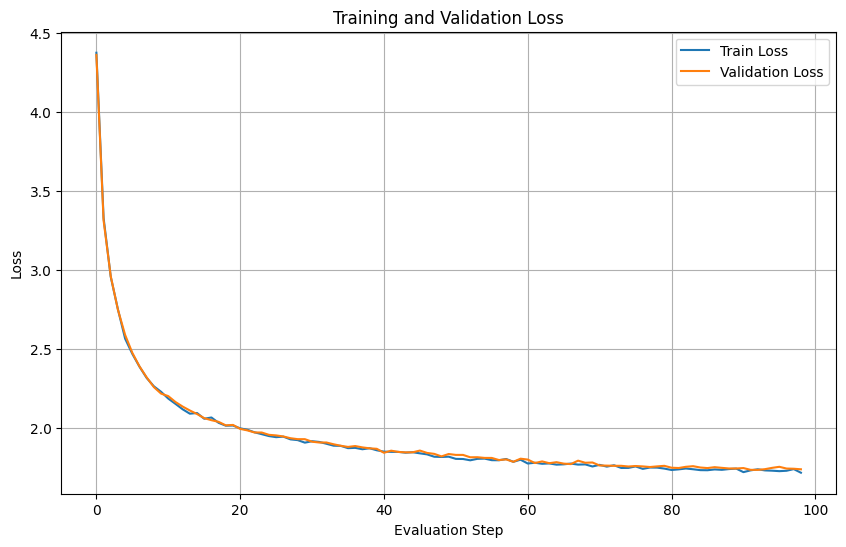

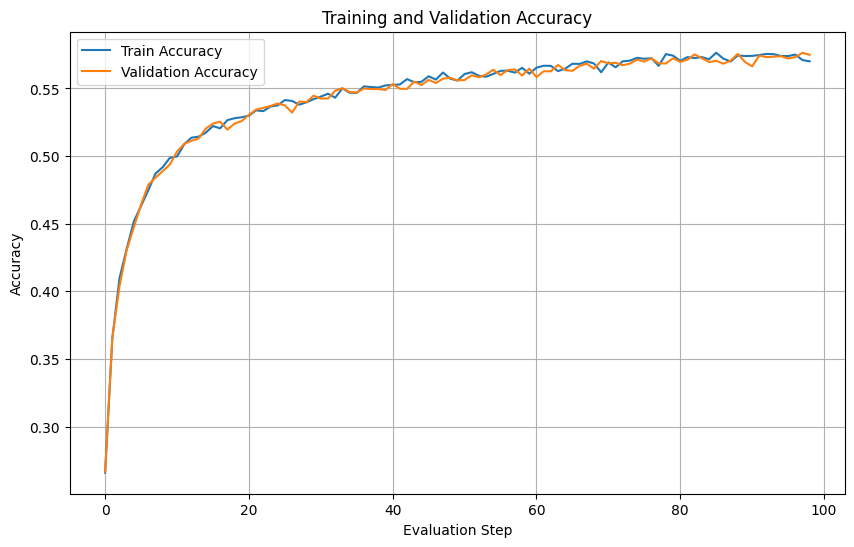

In [19]:

import matplotlib.pyplot as plt
train_loss_list_converted = [float(i) for i in train_loss_list]
validation_loss_list_converted = [float(i) for i in validation_loss_list]

plt.figure(figsize=(10, 6))
plt.plot(train_loss_list_converted, label='Train Loss')
plt.plot(validation_loss_list_converted, label='Validation Loss')
plt.xlabel('Evaluation Step')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

if 'train_acc_list' in globals() and len(train_acc_list) > 0:
    plt.figure(figsize=(10, 6))
    plt.plot(train_acc_list, label='Train Accuracy')
    plt.plot(validation_acc_list, label='Validation Accuracy')
    plt.xlabel('Evaluation Step')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()


## Step 10: Run SLM Inference on our trained model

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import tiktoken
from dataclasses import dataclass

@dataclass
class GPTConfig:
    block_size: int
    vocab_size: int
    n_layer: int
    n_head: int
    n_embd: int
    dropout: float = 0.0
    bias: bool = True

class LayerNorm(nn.Module):
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None
    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.flash = hasattr(F, 'scaled_dot_product_attention')
        if not self.flash:
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                       .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        if self.flash:
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=None, dropout_p=self.attn_dropout.p if self.training else 0.0, is_causal=True)
        else:
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)
    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1 = LayerNorm(config.n_embd, config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln2 = LayerNorm(config.n_embd, config.bias)
        self.mlp = MLP(config)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size, config.n_embd),
            wpe=nn.Embedding(config.block_size, config.n_embd),
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f=LayerNorm(config.n_embd, config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight  # weight tying

        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size
        pos = torch.arange(0, t, dtype=torch.long, device=device)

        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
            return logits, loss
        else:
            logits = self.lm_head(x[:, [-1], :])
            return logits, None

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """
        Generate tokens given a conditioning sequence.
        idx: Tensor of shape (B, T)
        """
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

device = "cuda" if torch.cuda.is_available() else "cpu"
enc = tiktoken.get_encoding("gpt2")
# Load the best available checkpoint
load_path = best_model_params_path if 'best_model_params_path' in globals() else './final_run/final_optuna_best_best_model.pt'
ckpt = torch.load(load_path, map_location='cpu')
config = GPTConfig(**ckpt['config'])
model = GPT(config).to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()


GPT(
  (transformer): ModuleDict(
    (wte): Embedding(50257, 320)
    (wpe): Embedding(128, 320)
    (drop): Dropout(p=0.06301031859705591, inplace=False)
    (h): ModuleList(
      (0-4): 5 x Block(
        (ln1): LayerNorm()
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=320, out_features=960, bias=False)
          (c_proj): Linear(in_features=320, out_features=320, bias=False)
          (attn_dropout): Dropout(p=0.06301031859705591, inplace=False)
          (resid_dropout): Dropout(p=0.06301031859705591, inplace=False)
        )
        (ln2): LayerNorm()
        (mlp): MLP(
          (c_fc): Linear(in_features=320, out_features=1280, bias=False)
          (gelu): GELU(approximate='none')
          (c_proj): Linear(in_features=1280, out_features=320, bias=False)
          (dropout): Dropout(p=0.06301031859705591, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm()
  )
  (lm_head): Linear(in_features=320, out_features=50257, bias=False)
)

In [18]:
sentence = "Once upon a time there was a Fish."
context = (torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(dim = 0))
y = model.generate(context, 200)
print(enc.decode(y.squeeze().tolist()))

Once upon a time there was a Fish. The Fish lived in the sea. One day a little girl came to help. She looked for the Fish. They looked high and low. But the baby said that the Fish wasn't clear anymore.

The Fish were sad, but then they heard a noise. It was a man digging up the sea. He had a key in his toolbox! The little girl opened the box and said "What are you doing?"

The doctor smiled and said that the little girl had saved the day. Together they were able to save up the sea. All their lives around the sea were safe and they did not worry when they came down.Once upon a time there was a sand turtle called Bob. Bob was feeling quite sad. He had no friends, until one day he saw an seagull. Bob looked up and asked the seagull if he could say, "Hello my friends!" The seagull looked up and said, "Yes, please give me your friends."


In [22]:
sentence = "A little lion went to the jungle"
context = (torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(dim = 0))
y = model.generate(context, 200)
print(enc.decode(y.squeeze().tolist()))

A little lion went to the jungle to look for food and found a cool food to eat. The lion was very hungry and ate all the food in his mouth. The king wanted to eat lots of bones, but he didn't know how. Then, one day, he went to the jungle and bought a food. He used it to eat many things and share with his friends. The lion was very happy he got the food and he continued to use the spears he found.Once upon a time, there was a little girl named Lily. She loved playing in the woods near her house. One day, she saw a big log near the river. She wanted to find out what was on the log, so she started walking towards it. Suddenly, the log started to move and it opened up. 

Lily discovered a bunny with some poison on the ground. She wondered who it would be and where it came from. She didn't like bugs or bugs, so she decided to hide her cave behind the log.


In [ ]:
import shutil 

shutil.make_archive('final_run_download', 
                    'zip', 
                    './checkpoints', 
                    'final_run')

In [26]:
import shutil
shutil.make_archive('/teamspace/studios/this_studio/final_run_download', 'zip', '/teamspace/studios/this_studio/checkpoints', 'final_run')

'/teamspace/studios/this_studio/final_run_download.zip'

In [19]:
def count_params(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_params = total_params - trainable_params
    return total_params, trainable_params, frozen_params

In [20]:
total_params, trainable_params, frozen_params = count_params(model)
print("Total params:", total_params)
print("Trainable params:", trainable_params)
print("Frozen params:", frozen_params)

Total params: 22270720
Trainable params: 22270720
Frozen params: 0
